In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
save_path = Path("../../data/combined")

In [3]:
sold = pd.read_csv(save_path/"sold.csv")

C:\Users\alext\AppData\Local\Temp\ipykernel_3776\2557060698.py:1: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: ListAgentEmail, 3: FireplaceYN, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType, 7: latfilled, 8: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv(save_path/"sold.csv")


In [4]:
sold.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [5]:
# Identify number of rows/columns
sold.shape

(414184, 84)

In [6]:
pd.options.display.max_rows = 100

In [7]:
listing = pd.read_csv(save_path/"listing.csv")

sold_columns = []
listing_columns = []
for c in sold.columns:
    sold_columns.append(c)
for c in listing.columns:
    listing_columns.append(c)

print(list(set(sold_columns)-set(listing_columns)))
print(list(set(listing_columns)-set(sold_columns)))

C:\Users\alext\AppData\Local\Temp\ipykernel_3776\529776706.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  listing = pd.read_csv(save_path/"listing.csv")


['Flooring', 'ViewYN', 'OriginatingSystemSubName', 'OriginatingSystemName', 'latfilled', 'lonfilled', 'PoolPrivateYN', 'ListAgentAOR', 'BasementYN', 'WaterfrontYN', 'BuyerAgentAOR']
['PropertyType.1', 'BuyerOfficeName.1', 'DaysOnMarket.1', 'UnparsedAddress.1', 'CloseDate.1', 'Longitude.1', 'ListAgentLastName.1', 'LivingArea.1', 'Latitude.1', 'ListPrice.1', 'ListAgentFirstName.1']


In [8]:
sold[['BasementYN', 'OriginatingSystemSubName', 'lonfilled', 'Flooring', 'WaterfrontYN', 'ViewYN', 'PoolPrivateYN', 'ListAgentAOR', 'OriginatingSystemName', 'latfilled', 'BuyerAgentAOR']].dtypes

BasementYN                  object
OriginatingSystemSubName       str
lonfilled                   object
Flooring                       str
WaterfrontYN                object
ViewYN                      object
PoolPrivateYN               object
ListAgentAOR                   str
OriginatingSystemName          str
latfilled                   object
BuyerAgentAOR                  str
dtype: object

In [9]:
# Review column data types
sold.dtypes

BuyerAgentAOR                       str
ListAgentAOR                        str
Flooring                            str
ViewYN                           object
WaterfrontYN                     object
BasementYN                       object
PoolPrivateYN                    object
OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                      str
CloseDate                           str
ClosePrice                      float64
ListAgentFirstName                  str
ListAgentLastName                   str
Latitude                        float64
Longitude                       float64
UnparsedAddress                     str
PropertyType                        str
LivingArea                      float64
ListPrice                       float64
DaysOnMarket                      int64
ListOfficeName                      str
BuyerOfficeName                     str
CoListOfficeName                    str
ListAgentFullName                   str


## Dtypes changes
* BasementYN (Bool)
* WaterfrontYN (Bool)
* ViewYN (Bool)
* PoolPrivateYN (Bool)
* 
* OriginalListPrice (int)
* CloseDate (DateTime)
* FireplacesTotal (int)
* AttachedGarageYN (bool)
* YearBuilt (int)
* StreetNumberNumeric (int)
* BathroomsTotalInteger (int)
* TaxYear (int)
* BedroomsTotal (int)
* ContractStatusChangeDate (DateTime)
* ElementarySchoolDistrict (string)
* PurchaseContractDate (DateTime)
* ListingContractDate (DateTime)
* BusinessType
* FireplaceYN (Bool)
* Stories (Int)
* MainLevelBedrooms (Int)
* NewConstructionYN (Bool)

In [10]:
# Identify High-missing columns
# Calculate missing counts and percentages per column
# percent missing data per column
missing_count = sold.isnull().sum()
percent_missing = round(missing_count * 100 / len(sold), 2)
missing_value_df = pd.DataFrame(
    {
        'missing_count': missing_count,
        'percent_missing': percent_missing
    }
)
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df

,missing_count,percent_missing
CloseDate,0,0.00
ClosePrice,2,0.00
ListingKey,0,0.00
PropertyType,0,0.00
DaysOnMarket,0,0.00
ListOfficeName,0,0.00
ListPrice,0,0.00
ListingKeyNumeric,0,0.00
ListingId,0,0.00
BedroomsTotal,11,0.00


In [11]:
sold.describe().T

,count,mean,std,min,25%,50%,75%,max
OriginalListPrice,413425.0,1.225389e+06,6.708944e+06,0.000000e+00,5.850000e+05,8.250000e+05,1.299000e+06,1.390000e+09
ListingKey,414184.0,1.098130e+09,3.132483e+07,4.216785e+08,1.075489e+09,1.097308e+09,1.118685e+09,1.159569e+09
ClosePrice,414182.0,1.190837e+06,6.139778e+06,0.000000e+00,5.750000e+05,8.230000e+05,1.300000e+06,9.895000e+08
Latitude,398228.0,3.465264e+01,1.708008e+00,-1.174725e+02,3.373584e+01,3.404647e+01,3.455423e+01,5.613037e+01
Longitude,398228.0,-1.185687e+02,2.977798e+00,-1.776467e+02,-1.188820e+02,-1.180144e+02,-1.172672e+02,3.290000e+02
LivingArea,413950.0,1.903791e+03,2.647205e+04,0.000000e+00,1.248000e+03,1.642000e+03,2.219000e+03,1.702132e+07
ListPrice,414184.0,1.140479e+06,1.359466e+06,5.250000e+02,5.760000e+05,8.150000e+05,1.295000e+06,1.375000e+08
DaysOnMarket,414184.0,3.736125e+01,5.359919e+01,-2.880000e+02,8.000000e+00,1.800000e+01,4.800000e+01,1.243000e+04
FireplacesTotal,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AboveGradeFinishedArea,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Review column data types
sold.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

# Market Analysis Fields FIX
* OriginalListPrice
* CloseDate
* ClosePrice
* Latitude
* Longitude
* PropertyType
* LivingArea
* ListPrice
* DaysOnMarket
* FireplacesTotal
* AssociationFeeFrequency
* AboveGradeFinishedArea
* TaxAnnualAmount
* CountyOrParish
* ElementarySchool
* AttachedGarageYN
* ParkingTotal
* PropertySubType
* LotSizeAcres
* YearBuilt
* BathroomsTotalInteger
* City
* BuildingAreaTotal
* BedroomsTotal
* BelowGradeFinishedArea
* StateOrProvince
* CoveredSpaces
* FireplaceYN
* Stories
* HighSchool
* Levels
* LotSizeDimensions
* LotSizeArea
* MainLevelBedrooms
* NewConstructionYN
* GarageSpaces
* PostalCode
* AssociationFee
* LotSizeSquareFeet
* MiddleOrJuniorSchoolDistrict
* BasementYN
* Flooring
* WaterfrontYN
* ViewYN
* PoolPrivateYN

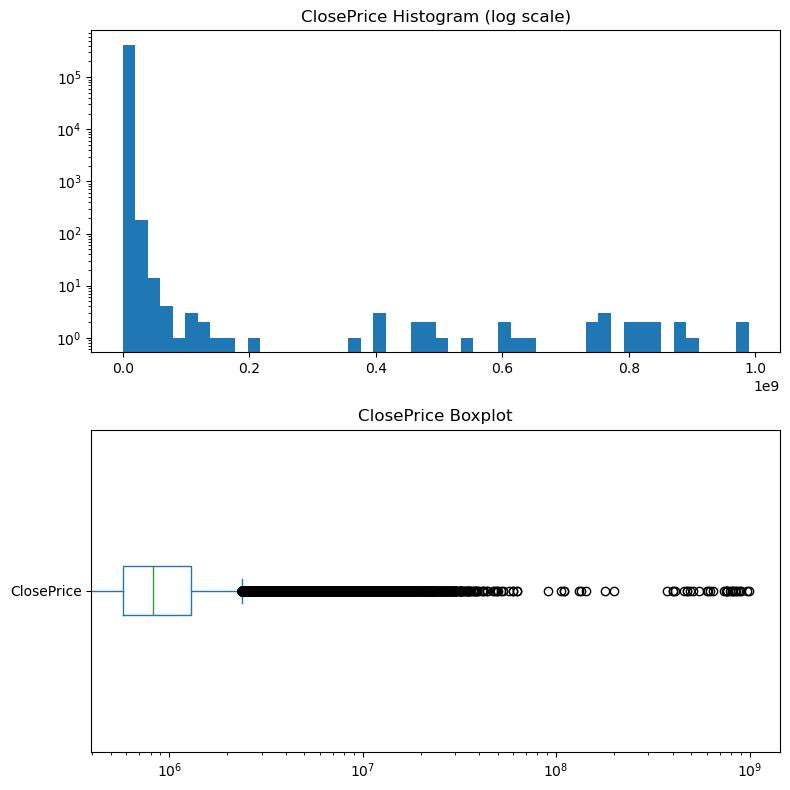

count    4.141820e+05
mean     1.190837e+06
std      6.139778e+06
min      0.000000e+00
25%      5.750000e+05
50%      8.230000e+05
75%      1.300000e+06
90%      2.065000e+06
95%      2.850000e+06
99%      5.568950e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['ClosePrice'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('ClosePrice Histogram (log scale)')

ax[1] = sold['ClosePrice'].plot(kind="box", logx=True, vert=False)
ax[1].set_title('ClosePrice Boxplot')

plt.tight_layout()
plt.show()
sold['ClosePrice'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

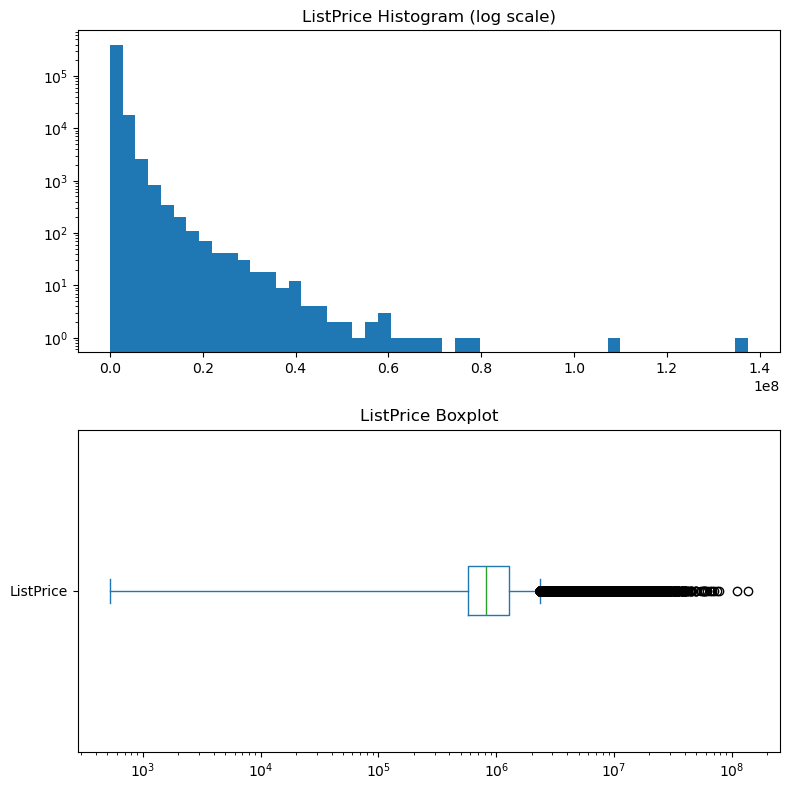

count    4.141840e+05
mean     1.140479e+06
std      1.359466e+06
min      5.250000e+02
25%      5.760000e+05
50%      8.150000e+05
75%      1.295000e+06
90%      1.999000e+06
95%      2.850000e+06
99%      5.700000e+06
max      1.375000e+08
Name: ListPrice, dtype: float64

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['ListPrice'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('ListPrice Histogram (log scale)')

ax[1] = sold['ListPrice'].plot(kind="box", logx=True, vert=False)
ax[1].set_title('ListPrice Boxplot')

plt.tight_layout()
plt.show()
sold['ListPrice'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

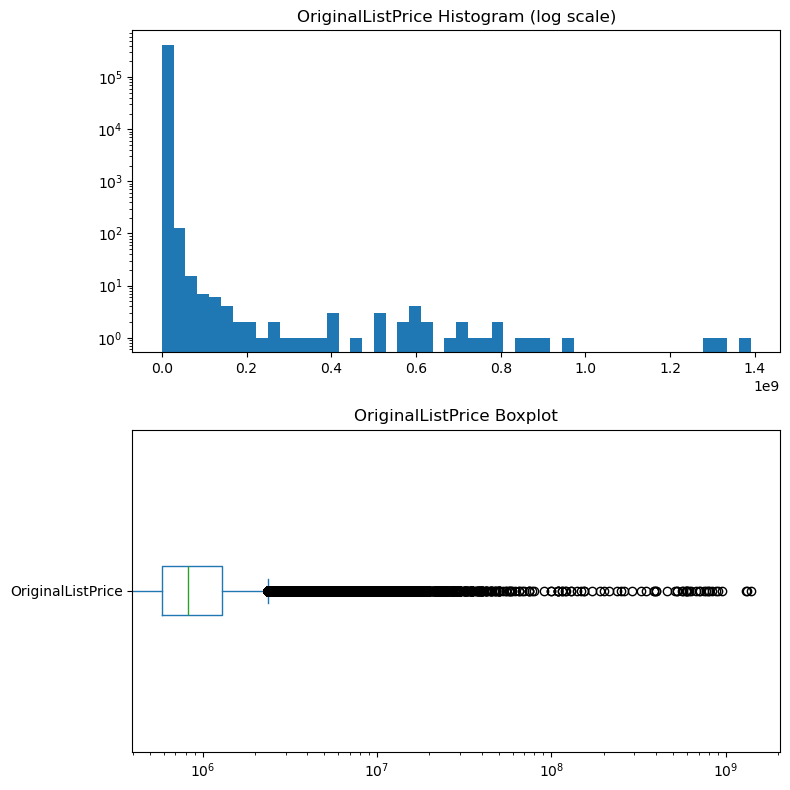

count    4.134250e+05
mean     1.225389e+06
std      6.708944e+06
min      0.000000e+00
25%      5.850000e+05
50%      8.250000e+05
75%      1.299000e+06
90%      2.068000e+06
95%      2.899999e+06
99%      5.995000e+06
max      1.390000e+09
Name: OriginalListPrice, dtype: float64

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['OriginalListPrice'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('OriginalListPrice Histogram (log scale)')

ax[1] = sold['OriginalListPrice'].plot(kind="box", logx=True, vert=False)
ax[1].set_title('OriginalListPrice Boxplot')

plt.tight_layout()
plt.show()
sold['OriginalListPrice'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

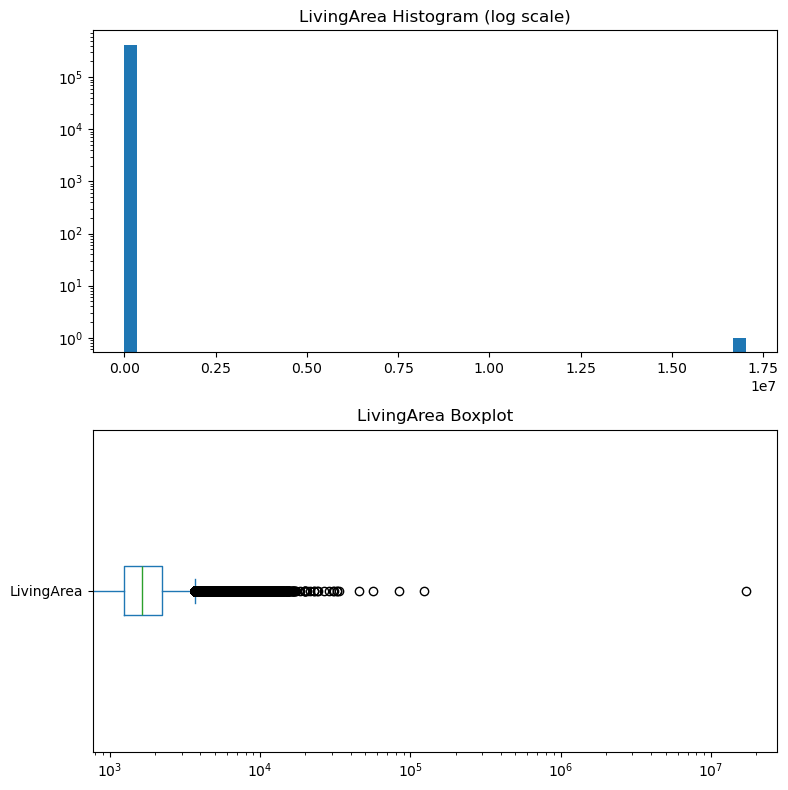

count    4.139500e+05
mean     1.903791e+03
std      2.647205e+04
min      0.000000e+00
25%      1.248000e+03
50%      1.642000e+03
75%      2.219000e+03
90%      2.977000e+03
95%      3.560000e+03
99%      5.282000e+03
max      1.702132e+07
Name: LivingArea, dtype: float64

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['LivingArea'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('LivingArea Histogram (log scale)')

ax[1] = sold['LivingArea'].plot(kind="box", logx=True, vert=False)
ax[1].set_title('LivingArea Boxplot')

plt.tight_layout()
plt.show()
sold['LivingArea'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

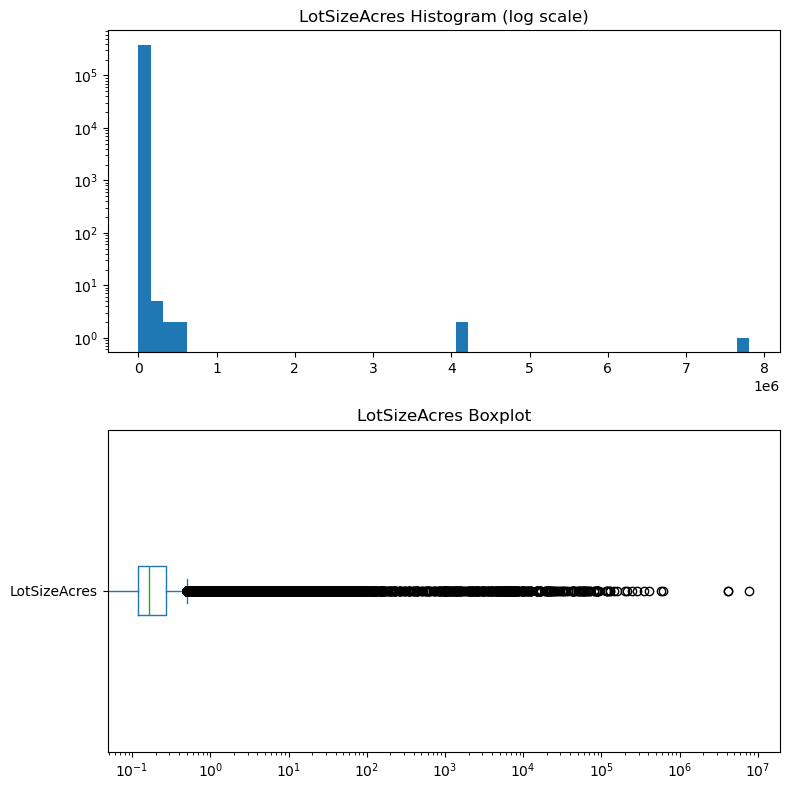

count    3.816200e+05
mean     6.628581e+01
std      1.599607e+04
min      0.000000e+00
25%      1.200000e-01
50%      1.664000e-01
75%      2.730000e-01
90%      1.047400e+00
95%      2.820010e+00
99%      1.083350e+01
max      7.810698e+06
Name: LotSizeAcres, dtype: float64

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['LotSizeAcres'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('LotSizeAcres Histogram (log scale)')

ax[1] = sold['LotSizeAcres'].plot(kind="box", logx=True, vert=False)
ax[1].set_title('LotSizeAcres Boxplot')

plt.tight_layout()
plt.show()
sold['LotSizeAcres'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

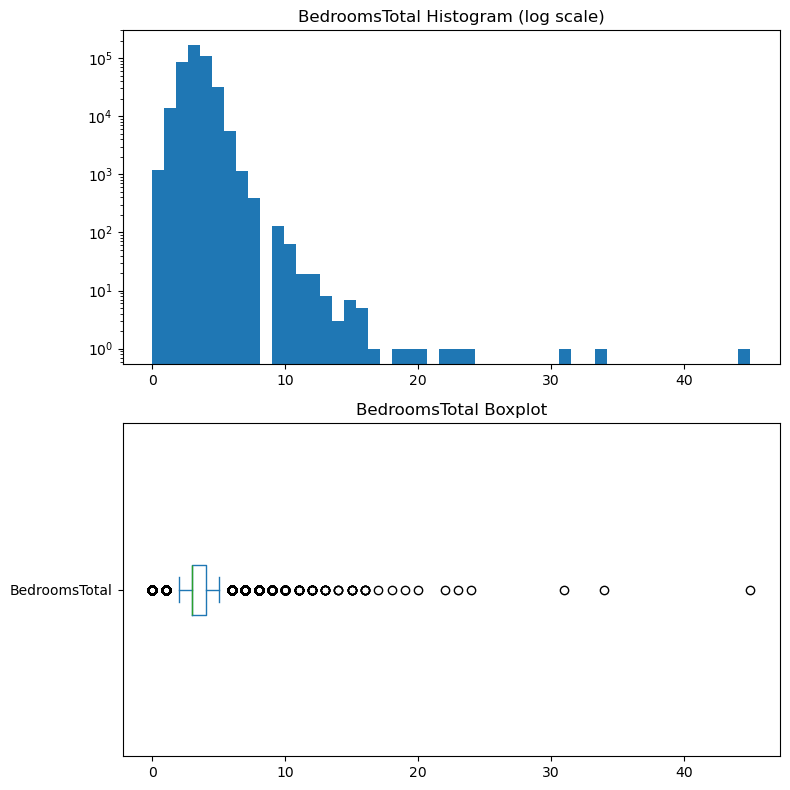

count    414173.000000
mean          3.201039
std           1.067087
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
90%           4.000000
95%           5.000000
99%           6.000000
max          45.000000
Name: BedroomsTotal, dtype: float64

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['BedroomsTotal'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('BedroomsTotal Histogram (log scale)')

ax[1] = sold['BedroomsTotal'].plot(kind="box", vert=False)
ax[1].set_title('BedroomsTotal Boxplot')

plt.tight_layout()
plt.show()
sold['BedroomsTotal'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

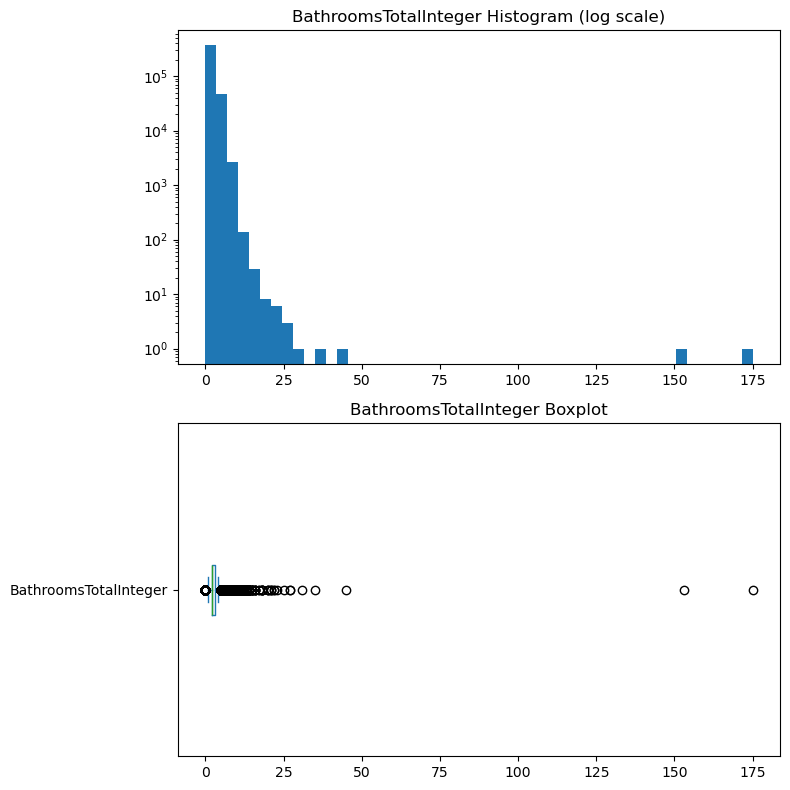

count    414115.000000
mean          2.534806
std           1.134169
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
90%           4.000000
95%           4.000000
99%           6.000000
max         175.000000
Name: BathroomsTotalInteger, dtype: float64

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['BathroomsTotalInteger'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('BathroomsTotalInteger Histogram (log scale)')

ax[1] = sold['BathroomsTotalInteger'].plot(kind="box", vert=False)
ax[1].set_title('BathroomsTotalInteger Boxplot')

plt.tight_layout()
plt.show()
sold['BathroomsTotalInteger'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

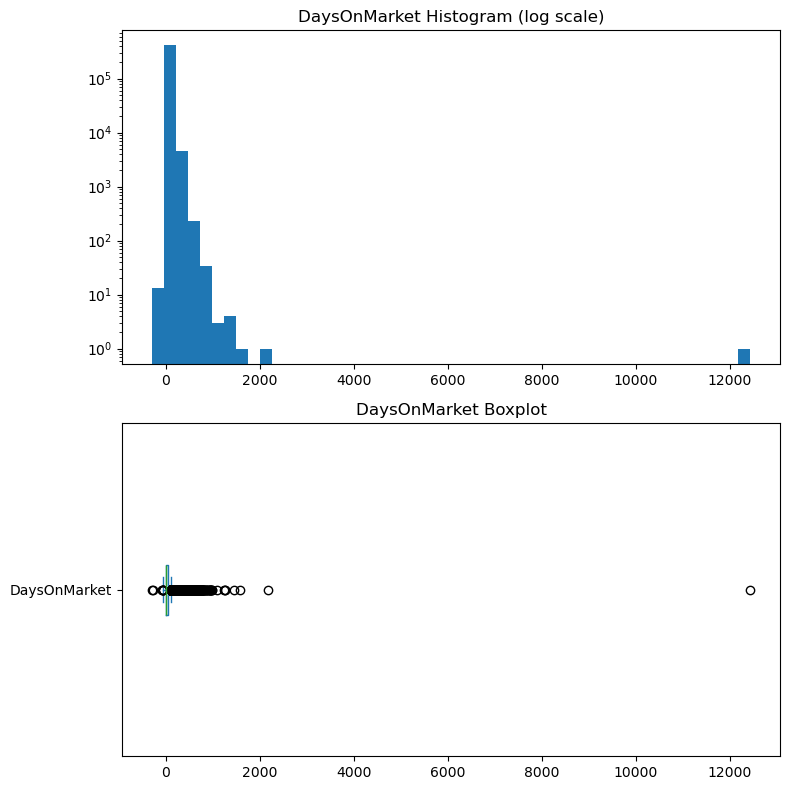

count    414184.000000
mean         37.361255
std          53.599186
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
90%          94.000000
95%         132.000000
99%         231.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['DaysOnMarket'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('DaysOnMarket Histogram (log scale)')

ax[1] = sold['DaysOnMarket'].plot(kind="box", vert=False)
ax[1].set_title('DaysOnMarket Boxplot')

plt.tight_layout()
plt.show()
sold['DaysOnMarket'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

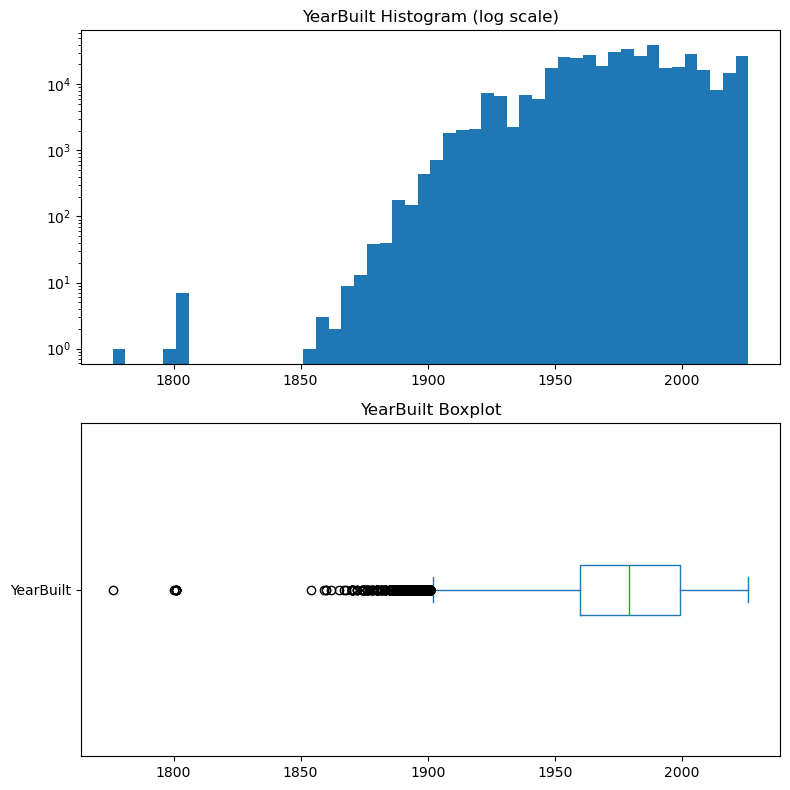

count    413812.000000
mean       1978.581726
std          26.279842
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        1999.000000
90%        2016.000000
95%        2022.000000
99%        2025.000000
max        2026.000000
Name: YearBuilt, dtype: float64

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].hist(sold['YearBuilt'], bins=50)
ax[0].set_yscale('log')
ax[0].set_title('YearBuilt Histogram (log scale)')

ax[1] = sold['YearBuilt'].plot(kind="box", vert=False)
ax[1].set_title('YearBuilt Boxplot')

plt.tight_layout()
plt.show()
sold['YearBuilt'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

## All of these follow the same structure of having the 99th percentile very large so it would be best if we removed them

# Reminder
- Change specified dtpyes
- Drop metadata columns
- Drop 99th percentile
- Drop missing columns